<a href="https://colab.research.google.com/github/safoura-banihashemi/qwen-terminal-finetuning/blob/main/qwen_terminal_pro_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Qwen3-0.6B · Terminal RL Fine-tuning

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_ROOT = '/content/drive/MyDrive/qwen_rl'
os.makedirs(SAVE_ROOT, exist_ok=True)
print(f'Save root: {SAVE_ROOT}')

Mounted at /content/drive
Save root: /content/drive/MyDrive/qwen_rl


## 1 · GPU Check

In [2]:
import subprocess, sys, torch

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU detected. Change runtime type → GPU')

import torch
print(f'\nPyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {total:.1f} GB')
    print('Model: Qwen3-0.6B')

Sat May  9 17:28:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2 · Install Dependencies

In [3]:
# Pinned versions for reproducibility
%pip install -q transformers==4.51.3 datasets peft accelerate bitsandbytes
%pip install -q trl==0.17.0
%pip install -q huggingface_hub evaluate
#%pip install flash-attn --no-build-isolation 2>/dev/null || echo 'flash-attn skipped (needs CUDA 11.8+)'

print('\nAll packages ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00

All packages ready.


In [4]:
import os, re, subprocess, textwrap, random
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType
from trl import GRPOConfig, GRPOTrainer
import time

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import json, torch
from huggingface_hub import login, HfApi

## 3 · Configuration


In [6]:
# CONFIGURATION
MODEL_ID = 'Qwen/Qwen3-0.6B'
HF_REPO  = 'safoura00/qwen-terminal-finetuning'

# Training
NUM_EPISODES = 500    # Total RL tasks that model practices
BATCH_SIZE = 32       # For each task model tries 32 different taskes at once
NUM_GENERATIONS = 4   # For each task, model tries 4 different answers (GRPO)
MAX_NEW_TOKENS = 64
LR = 1e-5
LORA_R = 16           # How many new connections adding
LORA_ALPHA = 32       # Scailing factor (2 x Rank)

# Pro-specific trainer knobs
WARMUP_STEPS = 20     # short warmup is enough
MAX_GRAD_NORM = 1.0   # relaxed from 0.3
SAVE_STEPS = 250      # only 2 mid-run saves
GRADIENT_CHECKPOINTING = False # OFF — we have VRAM; gains ~25 % speed

# Paths
os.makedirs(SAVE_ROOT, exist_ok=True)

print('configuration:')
for k, v in dict(
    MODEL_ID=MODEL_ID, HF_REPO=HF_REPO,
    NUM_EPISODES=NUM_EPISODES, BATCH_SIZE=BATCH_SIZE,
    NUM_GENERATIONS=NUM_GENERATIONS, LR=LR,
    GRADIENT_CHECKPOINTING=GRADIENT_CHECKPOINTING,
    SAVE_STEPS=SAVE_STEPS,
).items():
    print(f'  {k:<26}: {v}')

configuration:
  MODEL_ID                  : Qwen/Qwen3-0.6B
  HF_REPO                   : safoura00/qwen-terminal-finetuning
  NUM_EPISODES              : 500
  BATCH_SIZE                : 32
  NUM_GENERATIONS           : 4
  LR                        : 1e-05
  GRADIENT_CHECKPOINTING    : False
  SAVE_STEPS                : 250


## 4 · Terminal Gym (SETA-style Environment)

In [7]:
@dataclass
class TerminalTask:
    task_id          : str
    description      : str
    expected_command : str
    accepted_patterns: List[str] = field(default_factory=list)
    setup_cmd        : Optional[str] = None
    reward_partial   : float = 0.5

TASK_CATALOGUE: List[TerminalTask] = [
    # File system
    TerminalTask('ls-l',      'List all files in the current directory with details',
                 'ls -la', [r'ls\s+-[al]+']),
    TerminalTask('mkdir',     'Create a directory called projects',
                 'mkdir projects', [r'mkdir\s+-?p?\s*projects']),
    TerminalTask('find-py',   'Find all Python files recursively from current dir',
                 'find . -name "*.py"', [r'find\s+\.?\s+-name\s+["\']?\*\.py']),
    TerminalTask('cp-r',      'Copy directory src/ to backup/',
                 'cp -r src/ backup/', [r'cp\s+-r\w*\s+src/?\s+backup/?']),
    TerminalTask('rm-rf',     'Remove directory tmp/ and all its contents',
                 'rm -rf tmp/', [r'rm\s+-rf?\s+tmp/?']),
    TerminalTask('chmod',     'Make a file called run.sh executable',
                 'chmod +x run.sh', [r'chmod\s+\+x\s+run\.sh', r'chmod\s+7[0-7]{2}\s+run\.sh']),
    # Text processing
    TerminalTask('grep-r',    'Search recursively for the word TODO in all files',
                 'grep -r "TODO" .', [r'grep\s+-r[ni]*\s+["\']?TODO']),
    TerminalTask('wc-l',      'Count the number of lines in file data.txt',
                 'wc -l data.txt', [r'wc\s+-l\s+data\.txt']),
    TerminalTask('sort-u',    'Sort file words.txt and remove duplicates',
                 'sort -u words.txt', [r'sort\s+-u\s+words\.txt', r'sort\s+words\.txt\s+\|\s+uniq']),
    TerminalTask('awk-sum',   'Print only lines 5 to 10 of file log.txt',
                 'sed -n 5,10p log.txt', [r'sed\s+-n\s+5,10p\s+log\.txt', r'awk\s+.*NR>=5.*NR<=10']),
    TerminalTask('tail-f',    'Follow the end of a log file called server.log in real time',
                 'tail -f server.log', [r'tail\s+-f\s+server\.log']),
    # Process / system
    TerminalTask('ps-aux',    'Show all running processes with CPU and memory usage',
                 'ps aux', [r'ps\s+aux', r'ps\s+-aux', r'top']),
    TerminalTask('kill-9',    'Forcefully kill a process with PID 1234',
                 'kill -9 1234', [r'kill\s+-9\s+1234', r'kill\s+-SIGKILL\s+1234']),
    TerminalTask('df-h',      'Show disk usage in human-readable format',
                 'df -h', [r'df\s+-h']),
    TerminalTask('free-m',    'Show available memory in megabytes',
                 'free -m', [r'free\s+-[mh]']),
    # Network
    TerminalTask('curl-url',  'Download the content of https://example.com',
                 'curl https://example.com', [r'curl\s+https?://example\.com', r'wget\s+https?://example\.com']),
    TerminalTask('ping',      'Ping google.com 4 times',
                 'ping -c 4 google.com', [r'ping\s+-c\s+4\s+google\.com']),
    # Git
    TerminalTask('git-clone', 'Clone a repository from https://github.com/user/repo',
                 'git clone https://github.com/user/repo', [r'git\s+clone\s+https?://github\.com/user/repo']),
    TerminalTask('git-log',   'Show the last 5 git commits in one line each',
                 'git log --oneline -5', [r'git\s+log\s+.*-[n]?\s*5|git\s+log\s+--oneline\s+-5']),
    TerminalTask('git-diff',  'Show unstaged changes in the current git repository',
                 'git diff', [r'git\s+diff(?!\s+--cached)']),
    # Python / pip
    TerminalTask('pip-install','Install the requests library using pip',
                 'pip install requests', [r'pip\s+install\s+requests', r'pip3\s+install\s+requests']),
    TerminalTask('python-run', 'Run a Python script called train.py',
                 'python train.py', [r'python\d*\s+train\.py']),
]


class TerminalGym:
    SYSTEM_PROMPT = textwrap.dedent("""
        You are a Linux terminal expert. Given a task description, respond with
        ONLY the exact terminal command — no explanation, no markdown, no extra text.
        Output a single command on one line.
    """).strip()

    def __init__(self, tasks=TASK_CATALOGUE):
        self.tasks   = {t.task_id: t for t in tasks}
        self.history : List[Dict] = []

    def build_prompt(self, task: TerminalTask) -> str:
        return f"{self.SYSTEM_PROMPT}\n\nTask: {task.description}\nCommand:"

    def grade(self, task: TerminalTask, response: str) -> float:
        cmd = response.strip().split('\n')[0].strip()
        if cmd == task.expected_command:
            return 1.0
        for pat in task.accepted_patterns:
            if re.search(pat, cmd):
                return 1.0
        core = task.expected_command.split()[0]
        if core in cmd:
            return task.reward_partial
        return 0.0

    def sample_tasks(self, n: int) -> List[TerminalTask]:
        return random.choices(list(self.tasks.values()), k=n)

    def record(self, task_id, response, reward):
        self.history.append({'task_id': task_id, 'response': response, 'reward': reward})


gym = TerminalGym()
print(f'Terminal Gym ready — {len(gym.tasks)} tasks')
sample = list(gym.tasks.values())[0]
assert gym.grade(sample, sample.expected_command) == 1.0, 'Grader sanity check failed!'
print(f'Grader sanity check passed for task "{sample.task_id}"')

Terminal Gym ready — 22 tasks
Grader sanity check passed for task "ls-l"


## 5 · Load Qwen3 Model

In [8]:
# Tokenizer
print(f'Loading tokenizer from {MODEL_ID} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'   # required for decoder-only batch generation
print('Tokenizer ready.')

# 4-bit quantisation
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Auto-select attention backend — flash_attention_2 if installed, else eager
try:
    import flash_attn
    attn_impl = 'flash_attention_2'
    print('flash_attention_2 enabled (L4 optimized, ~8x faster generation)')
except ImportError:
    attn_impl = 'eager'
    print('Using eager attention (flash-attn not installed)')


print(f'\nLoading {MODEL_ID} in 4-bit ...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    attn_implementation=attn_impl,
)
print('Base model loaded.')

# LoRA adapters
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print('LoRA adapters attached.')

Loading tokenizer from Qwen/Qwen3-0.6B ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Tokenizer ready.
Using eager attention (flash-attn not installed)

Loading Qwen/Qwen3-0.6B in 4-bit ...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Base model loaded.
trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650
LoRA adapters attached.


## 6 · Build GRPO Dataset

In [9]:
from datasets import Dataset

random.seed(42)
all_tasks  = list(gym.tasks.values())
n_train    = NUM_EPISODES * BATCH_SIZE

train_samples = []
for _ in range(n_train):
    task = random.choice(all_tasks)
    train_samples.append({
        'prompt' : gym.build_prompt(task),
        'task_id': task.task_id,
    })

train_dataset = Dataset.from_list(train_samples)
print(f'GRPO dataset: {len(train_dataset)} samples ({NUM_EPISODES} episodes x {BATCH_SIZE} batch)')
print('\nFirst sample prompt:')
print(train_dataset[0]['prompt'])

GRPO dataset: 16000 samples (500 episodes x 32 batch)

First sample prompt:
You are a Linux terminal expert. Given a task description, respond with
ONLY the exact terminal command — no explanation, no markdown, no extra text.
Output a single command on one line.

Task: Install the requests library using pip
Command:


## 7 · Reward Function & GRPO Trainer

In [10]:
# Reward function
# GRPOTrainer passes a flat list of BATCH_SIZE * NUM_GENERATIONS completions.
def terminal_reward(prompts: list, completions: list, task_id=None, **kwargs) -> list:
    rewards = []
    for i, completion in enumerate(completions):
        prompt_idx = i // NUM_GENERATIONS
        tid  = task_id[prompt_idx] if task_id is not None else None
        task = gym.tasks.get(tid)   if tid   is not None else None
        if task is None:
            rewards.append(0.0)
            continue
        r = gym.grade(task, completion)
        gym.record(tid, completion, r)
        rewards.append(r)
    return rewards

# Auto-resume from checkpoint if one exists
CKPT_DIR    = os.path.join(SAVE_ROOT, 'checkpoints')
resume_from = None
if os.path.isdir(CKPT_DIR):
    ckpts = sorted(
        [d for d in os.listdir(CKPT_DIR) if d.startswith('checkpoint-')],
        key=lambda x: int(x.split('-')[-1])
    )
    if ckpts:
        resume_from = os.path.join(CKPT_DIR, ckpts[-1])
        print(f'Resuming from checkpoint: {resume_from}')
    else:
        print('No checkpoint found — starting fresh.')
else:
    print('No checkpoint dir found — starting fresh.')

# GRPOConfig — Pro L4 tuned
grpo_config = GRPOConfig(
    output_dir                  = CKPT_DIR,
    num_train_epochs            = 1,
    per_device_train_batch_size = BATCH_SIZE,           # 8
    num_generations             = NUM_GENERATIONS,
    max_completion_length       = MAX_NEW_TOKENS,
    learning_rate               = LR,                   # 1e-5
    warmup_steps                = WARMUP_STEPS,         # 20
    max_grad_norm               = MAX_GRAD_NORM,        # 1.0
    temperature                 = 0.7,                  # rollout diversity
    logging_steps               = 10,
    save_steps                  = SAVE_STEPS,           # 250
    save_total_limit            = 2,                    # keep 2 checkpoints only
    fp16                        = False,
    bf16                        = True,
    gradient_checkpointing      = GRADIENT_CHECKPOINTING,  # False
    gradient_accumulation_steps = 1,                    # no accumulation needed
    remove_unused_columns       = False,                # keep 'task_id' column
    report_to                   = 'none',
)

trainer = GRPOTrainer(
    model            = model,
    reward_funcs     = terminal_reward,
    args             = grpo_config,
    train_dataset    = train_dataset,
    processing_class = tokenizer,
)
print('GRPOTrainer ready.')
if resume_from:
    print(f'   Will resume from: {resume_from}')

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


No checkpoint dir found — starting fresh.
GRPOTrainer ready.


## 8 · Train

In [11]:
print('Starting RL fine-tuning...')
print(f'Episodes: {NUM_EPISODES}')
print(f'Batch: {BATCH_SIZE} prompts x {NUM_GENERATIONS} rollouts each')
print(f'Grad ckpt: {GRADIENT_CHECKPOINTING}')
print(f'LR: {LR}')
print(f'Checkpoints: every {SAVE_STEPS} steps -> {CKPT_DIR}')
print()

start = time.time()

try:
    trainer.train(resume_from_checkpoint=resume_from)
    elapsed = (time.time() - start) / 60
    print(f'\nTraining complete in {elapsed:.1f} minutes!')

except KeyboardInterrupt:
    print('\nInterrupted by user — saving current state to Drive...')
    trainer.save_model(os.path.join(SAVE_ROOT, 'qwen_rl_interrupted'))
    tokenizer.save_pretrained(os.path.join(SAVE_ROOT, 'qwen_rl_interrupted'))
    print('Model saved.')

except Exception as e:
    print(f'\nUnexpected error: {e}')
    trainer.save_model(os.path.join(SAVE_ROOT, 'qwen_rl_error_recovery'))
    tokenizer.save_pretrained(os.path.join(SAVE_ROOT, 'qwen_rl_error_recovery'))
    print('Emergency save complete.')
    raise

else:
    # Clean finish — save final model
    FINAL_DIR = os.path.join(SAVE_ROOT, 'qwen_rl_final')
    trainer.save_model(FINAL_DIR)
    tokenizer.save_pretrained(FINAL_DIR)
    print(f'Model saved to {FINAL_DIR}')

`generation_config` default values have been modified to match model-specific defaults: {'top_k': 20, 'top_p': 0.95, 'bos_token_id': 151643}. If this is not desired, please set these values explicitly.


Starting RL fine-tuning...
Episodes: 500
Batch: 32 prompts x 4 rollouts each
Grad ckpt: False
LR: 1e-05
Checkpoints: every 250 steps -> /content/drive/MyDrive/qwen_rl/checkpoints



Step,Training Loss
10,0.000000
20,0.000200
30,0.000200
40,0.000800
50,0.001400
60,0.001300
70,0.001100
80,0.001000
90,0.001100
100,0.001300



Training complete in 374.4 minutes!
Model saved to /content/drive/MyDrive/qwen_rl/qwen_rl_final


## 9 · Training Reward Curve

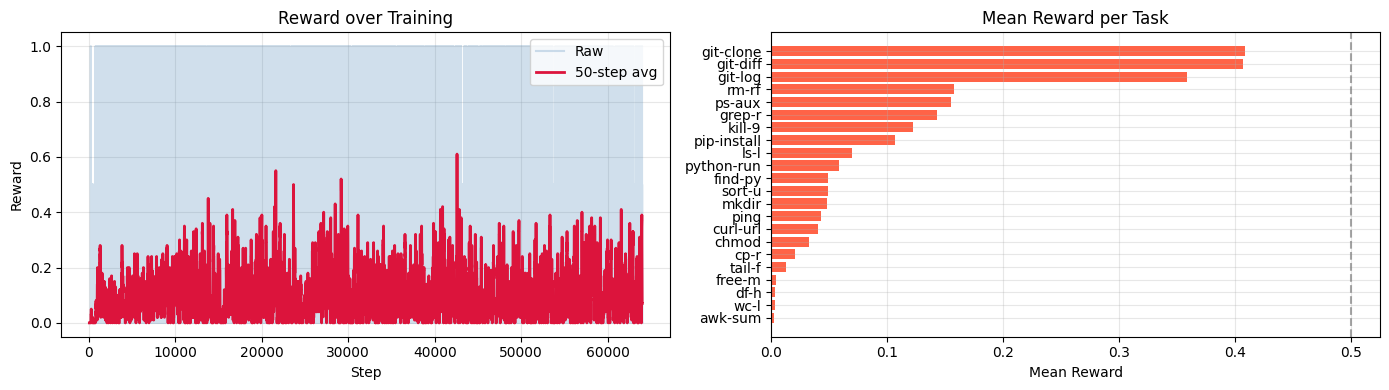

Overall mean reward : 0.105
Chart saved to      : /content/drive/MyDrive/qwen_rl/training_curves.png


In [12]:
if not gym.history:
    print('No history yet — run training first.')
else:
    rewards  = [h['reward'] for h in gym.history]
    window   = min(50, len(rewards) // 4 or 1)
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(rewards, alpha=0.25, color='steelblue', label='Raw')
    axes[0].plot(range(window-1, len(rewards)), smoothed, color='crimson',
                 linewidth=2, label=f'{window}-step avg')
    axes[0].set_title('Reward over Training')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Reward')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    task_rewards = defaultdict(list)
    for h in gym.history:
        task_rewards[h['task_id']].append(h['reward'])
    task_means   = {k: np.mean(v) for k, v in task_rewards.items()}
    sorted_tasks = sorted(task_means.items(), key=lambda x: x[1])
    names, vals  = zip(*sorted_tasks)

    axes[1].barh(names, vals,
                 color=['tomato' if v < 0.5 else 'seagreen' for v in vals])
    axes[1].set_title('Mean Reward per Task')
    axes[1].set_xlabel('Mean Reward')
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.7)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    chart_path = os.path.join(SAVE_ROOT, 'training_curves.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Overall mean reward : {np.mean(rewards):.3f}')
    print(f'Chart saved to      : {chart_path}')

## 10 · Benchmark: Fine-tuned Model

In [13]:
def evaluate_model(eval_model, eval_tokenizer, gym_instance, label='Model', max_new_tokens=64):
    eval_model.eval()
    results = []
    for task in gym_instance.tasks.values():
        prompt = gym_instance.build_prompt(task)
        inputs = eval_tokenizer(prompt, return_tensors='pt').to(eval_model.device)
        with torch.no_grad():
            output_ids = eval_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=eval_tokenizer.eos_token_id,
            )
        generated = output_ids[0][inputs['input_ids'].shape[1]:]
        response  = eval_tokenizer.decode(generated, skip_special_tokens=True).strip()
        reward    = gym_instance.grade(task, response)
        results.append({
            'task_id'    : task.task_id,
            'description': task.description,
            'expected'   : task.expected_command,
            'predicted'  : response,
            'reward'     : reward,
        })

    correct  = sum(1 for r in results if r['reward'] == 1.0)
    partial  = sum(1 for r in results if 0 < r['reward'] < 1.0)
    total    = len(results)
    return {
        'label'            : label,
        'total_tasks'      : total,
        'fully_correct'    : correct,
        'partially_correct': partial,
        'wrong'            : total - correct - partial,
        'accuracy'         : correct / total,
        'mean_reward'      : sum(r['reward'] for r in results) / total,
        'details'          : results,
    }

print('Evaluating fine-tuned model...')
ft_results = evaluate_model(model, tokenizer, gym, label='Fine-tuned (LoRA)')

print(f"\n{'='*52}")
print(f"Fine-tuned model results")
print(f"{'='*52}")
print(f"Accuracy: {ft_results['accuracy']:.1%}")
print(f"Mean rwd: {ft_results['mean_reward']:.3f}")
print(f"Correct: {ft_results['fully_correct']}/{ft_results['total_tasks']}")
print(f"Partial: {ft_results['partially_correct']}")
print(f"Wrong: {ft_results['wrong']}")

bench_path = os.path.join(SAVE_ROOT, 'benchmark_results.json')
with open(bench_path, 'w') as f:
    json.dump(ft_results, f, indent=2)
print(f'\nResults saved to {bench_path}')

Evaluating fine-tuned model...


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(



Fine-tuned model results
Accuracy: 31.8%
Mean rwd: 0.409
Correct: 7/22
Partial: 4
Wrong: 11

Results saved to /content/drive/MyDrive/qwen_rl/benchmark_results.json


In [14]:
# Per-task results table
print(f"\n{'Task ID':<15} {'Reward':>7}  {'Predicted':<42} Expected")
print('-' * 115)
for r in ft_results['details']:
    pred_short = r['predicted'][:40] + '..' if len(r['predicted']) > 42 else r['predicted']
    icon = '✅' if r['reward'] == 1.0 else ('🟡' if r['reward'] > 0 else '❌')
    print(f"{icon} {r['task_id']:<13} {r['reward']:>7.2f}  {pred_short:<42} {r['expected']}")


Task ID          Reward  Predicted                                  Expected
-------------------------------------------------------------------------------------------------------------------
🟡 ls-l             0.50  git ls-tree -r --name-sorted --name-sort.. ls -la
❌ mkdir            0.00  git clone https://github.com/your-userna.. mkdir projects
🟡 find-py          0.50  git find . -type f -name "*.py" -exec gr.. find . -name "*.py"
❌ cp-r             0.00  git clone https://github.com/username/re.. cp -r src/ backup/
✅ rm-rf            1.00  git rm -r tmp/ && git rm -r tmp/ && git .. rm -rf tmp/
❌ chmod            0.00  git clone https://github.com/username/re.. chmod +x run.sh
✅ grep-r           1.00  git grep -r TODO

Now, the task is to fi.. grep -r "TODO" .
❌ wc-l             0.00  git diff --count-lines --format=%d
Answe.. wc -l data.txt
🟡 sort-u           0.50  git sort --sort=sort:asc --sort=sort:asc.. sort -u words.txt
❌ awk-sum          0.00  git diff --color=none --git-me

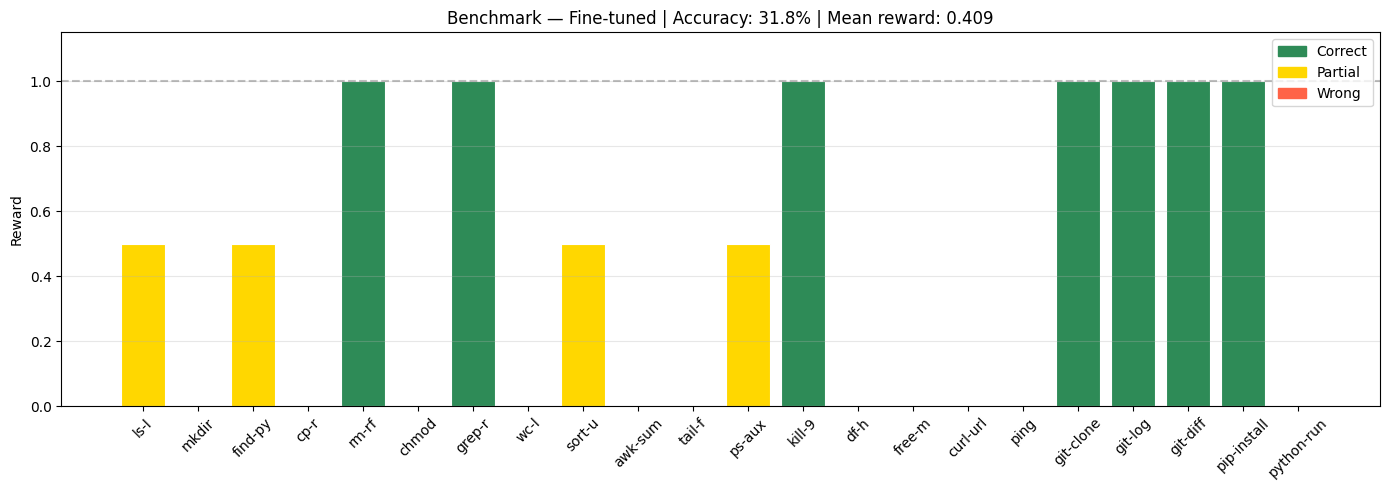

In [15]:
# Benchmark bar chart
details  = ft_results['details']
task_ids = [d['task_id'] for d in details]
rewards  = [d['reward']  for d in details]
colors   = ['seagreen' if r == 1.0 else 'gold' if r > 0 else 'tomato' for r in rewards]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(task_ids, rewards, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Reward')
ax.set_title(f'Benchmark — Fine-tuned | Accuracy: {ft_results["accuracy"]:.1%} | '
             f'Mean reward: {ft_results["mean_reward"]:.3f}')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='seagreen', label='Correct'),
                   Patch(color='gold',     label='Partial'),
                   Patch(color='tomato',   label='Wrong')], loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path2 = os.path.join(SAVE_ROOT, 'benchmark_chart.png')
plt.savefig(chart_path2, dpi=150, bbox_inches='tight')
plt.show()

## 11 · Upload to Hugging Face Hub

In [16]:
# login call
hf_token = os.environ.get('HUGGINGFACE_TOKEN')
if hf_token:
    login(token=hf_token)
    print('Logged in via HUGGINGFACE_TOKEN env var.')
else:
    print('HUGGINGFACE_TOKEN not set — launching interactive login:')
    login()

HUGGINGFACE_TOKEN not set — launching interactive login:


In [17]:
print(f'Pushing model to {HF_REPO} ...')
model.push_to_hub(HF_REPO, private=False)
tokenizer.push_to_hub(HF_REPO, private=False)
print('Model & tokenizer pushed!')

Pushing model to safoura00/qwen-terminal-finetuning ...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         |  553kB / 40.4MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp5drxaabq/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Model & tokenizer pushed!


In [18]:
api = HfApi()
for fname, fpath in [
    ('benchmark_results.json', os.path.join(SAVE_ROOT, 'benchmark_results.json')),
    ('benchmark_chart.png',    os.path.join(SAVE_ROOT, 'benchmark_chart.png')),
    ('training_curves.png',    os.path.join(SAVE_ROOT, 'training_curves.png')),
]:
    if os.path.exists(fpath):
        api.upload_file(path_or_fileobj=fpath, path_in_repo=fname,
                        repo_id=HF_REPO, repo_type='model')
        print(f'  Uploaded {fname}')

print(f'\nDone! https://huggingface.co/{HF_REPO}')

  Uploaded benchmark_results.json
  Uploaded benchmark_chart.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...en_rl/training_curves.png: 100%|##########|  107kB /  107kB            

  Uploaded training_curves.png

Done! https://huggingface.co/safoura00/qwen-terminal-finetuning


## 12 · Interactive Inference Demo

In [19]:
def ask_terminal(question: str, max_new_tokens: int = 64) -> str:
    system = (
        'You are a Linux terminal expert. Given a task description, respond with '
        'ONLY the exact terminal command — no explanation, no markdown, no extra text.'
    )
    prompt = f'{system}\n\nTask: {question}\nCommand:'
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip().split('\n')[0]

test_questions = [
    'Show all running processes sorted by memory usage',
    'Create a compressed tarball of the logs/ directory',
    'Find all files larger than 100MB',
    'Show the last 20 lines of /var/log/syslog',
    'Check which process is using port 8080',
]

print('Fine-tuned model predictions\n')
for q in test_questions:
    ans = ask_terminal(q)
    print(f'  Q: {q}')
    print(f'  A: {ans}\n')

Fine-tuned model predictions



/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


  Q: Show all running processes sorted by memory usage
  A: git clone https://github.com/username/repo.git

  Q: Create a compressed tarball of the logs/ directory
  A: tar -cz -f logs.tar.gz logs/

  Q: Find all files larger than 100MB
  A: git grep -R -f -e '^[0-9]{1,2}'

  Q: Show the last 20 lines of /var/log/syslog
  A: ?

  Q: Check which process is using port 8080
  A: curl -i http://localhost:8080

